In [9]:
import pandas as pd
df = pd.read_csv("test.csv")
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Task
Create a scatterplot showing the relationship between `Age` (x-axis) and `Work_Productivity_Score` (y-axis) from the existing DataFrame `df`, using a reasonable sample size to avoid overplotting.

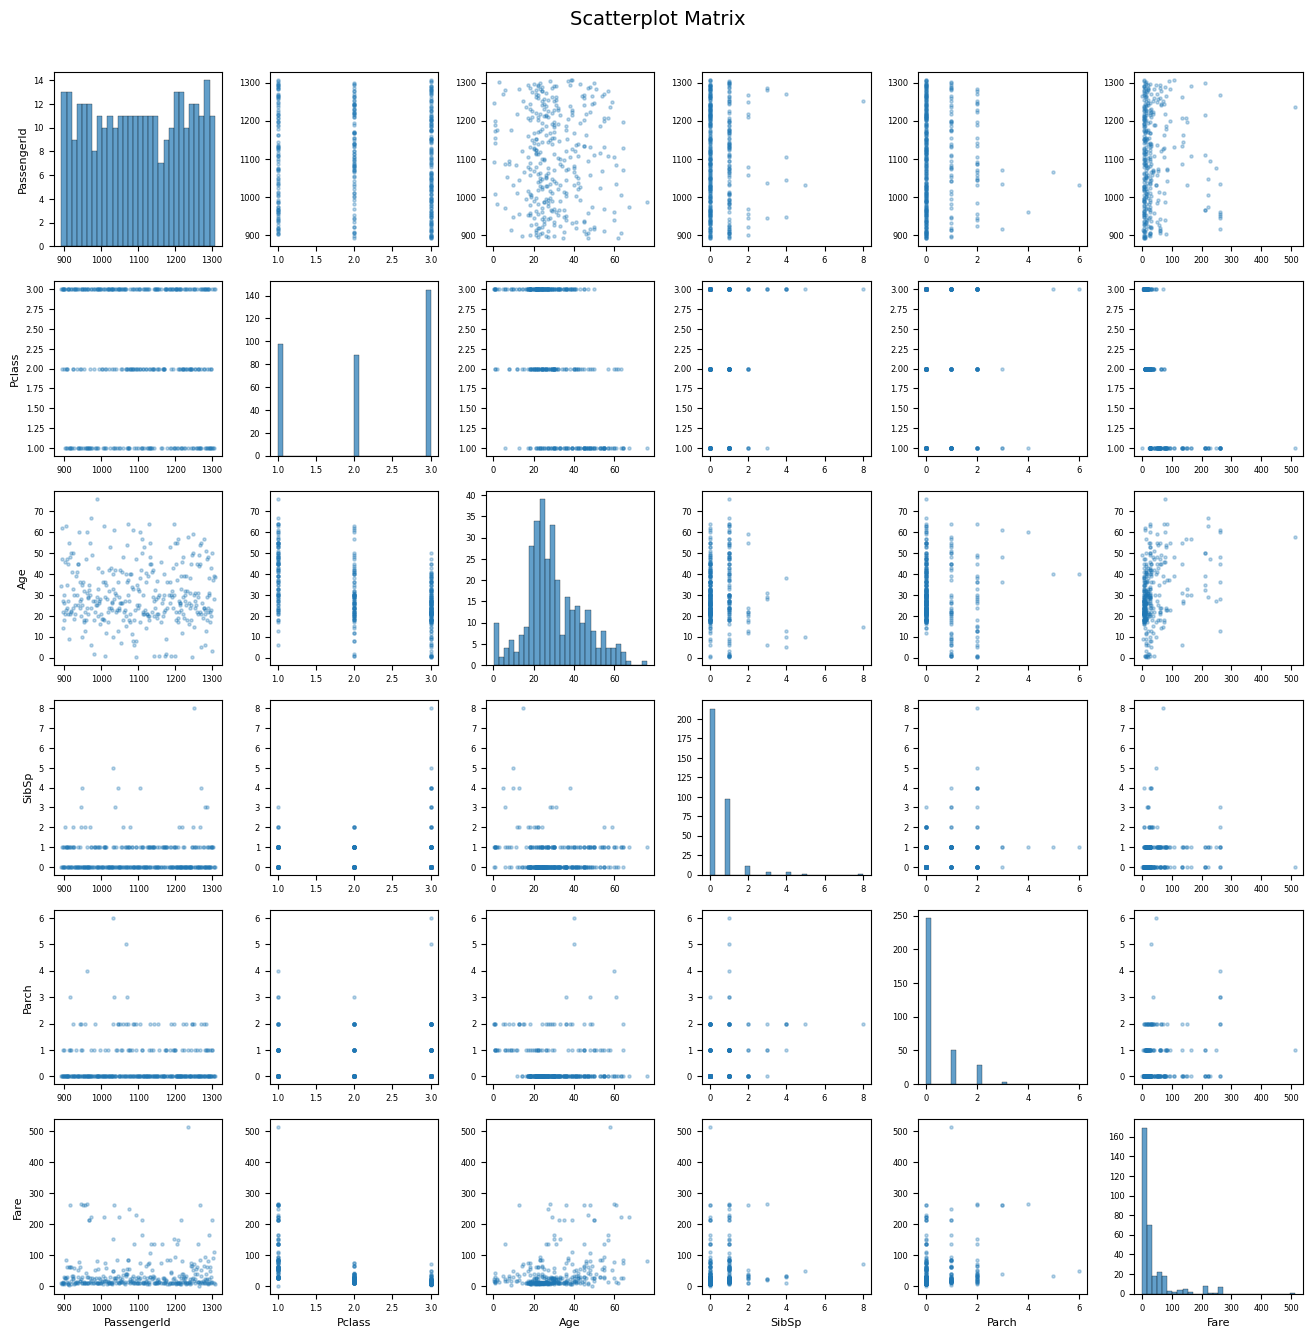

In [10]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns.tolist()
sample_df = df[numeric_cols].dropna()
n = min(3000, len(sample_df))
sample_df = sample_df.sample(n=n, random_state=42) if len(sample_df) > n else sample_df

num = len(numeric_cols)
fig, axes = plt.subplots(num, num, figsize=(max(num * 2.2, 10), max(num * 2.2, 10)))

for i, col_y in enumerate(numeric_cols):
    for j, col_x in enumerate(numeric_cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(sample_df[col_x], bins=30, alpha=0.7, edgecolor="black", linewidth=0.3)
        else:
            ax.scatter(sample_df[col_x], sample_df[col_y], s=5, alpha=0.3)
        if j == 0:
            ax.set_ylabel(col_y, fontsize=8)
        else:
            ax.set_ylabel("")
        if i == num - 1:
            ax.set_xlabel(col_x, fontsize=8)
        else:
            ax.set_xlabel("")
        ax.tick_params(labelsize=6)

fig.suptitle("Scatterplot Matrix", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


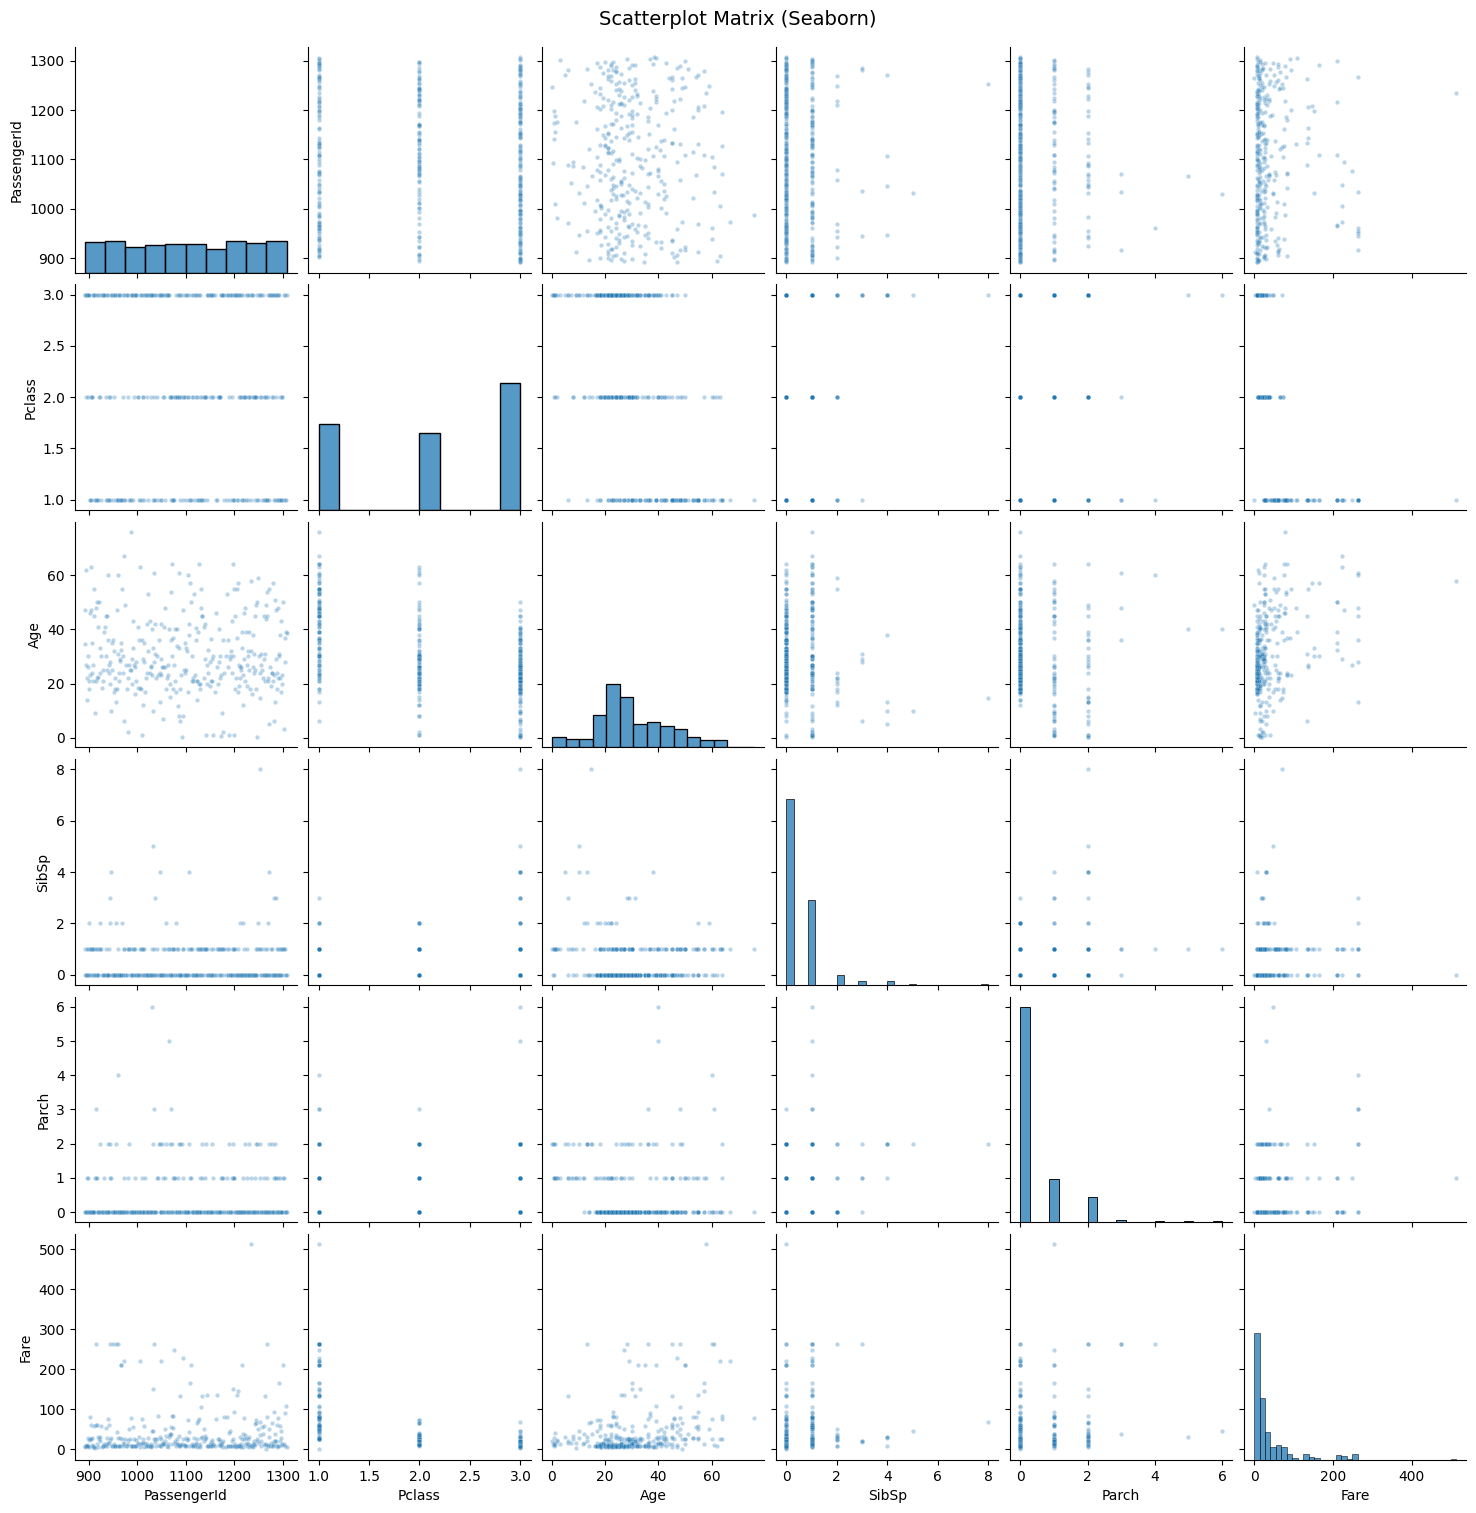

In [11]:
import seaborn as sns

sns.pairplot(sample_df, plot_kws={"s": 10, "alpha": 0.3}, diag_kind="hist")
plt.suptitle("Scatterplot Matrix (Seaborn)", fontsize=14, y=1.01)
plt.show()


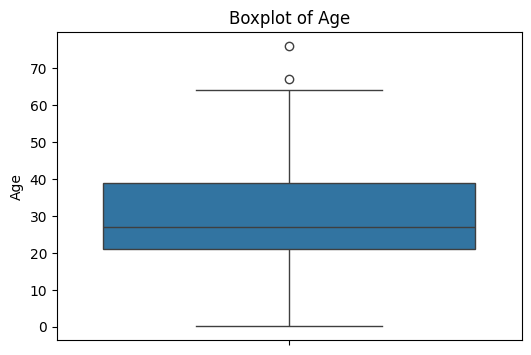

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# df = ...  # your pandas DataFrame

plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Age"])  # or: sns.boxplot(data=df, y="age")
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()